In [21]:
import pandas as pd
import numpy as np

# processed dataset
df = pd.read_csv("processed_data/processed_data.csv")

### Split Data

In [26]:
def stratified_split(X, y, val_size=0.15, test_size=0.15, random_state=42):
    np.random.seed(random_state)

    # Combine X and y
    full_df = X.copy()
    full_df[target_col] = y

    # Shuffle samples
    full_df = full_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    # Split by class
    delayed = full_df[full_df[target_col] == 1]
    ontime = full_df[full_df[target_col] == 0]

    def split_class(df_class):
        n = len(df_class)
        test_n = int(n * test_size)
        val_n = int(n * val_size)
        test_set = df_class.iloc[:test_n]
        val_set = df_class.iloc[test_n:test_n + val_n]
        train_set = df_class.iloc[test_n + val_n:]
        return train_set, val_set, test_set

    train_1, val_1, test_1 = split_class(delayed)
    train_0, val_0, test_0 = split_class(ontime)

    train_df = pd.concat([train_1, train_0]).sample(frac=1, random_state=random_state)
    val_df = pd.concat([val_1, val_0]).sample(frac=1, random_state=random_state)
    test_df = pd.concat([test_1, test_0]).sample(frac=1, random_state=random_state)

    return train_df, val_df, test_df

# updated function
train_df, val_df, test_df = stratified_split(X, y)

# undersampling step on train_df
minority_class_size = train_df[target_col].sum()
train_df_majority = train_df[train_df[target_col] == 0].sample(n=minority_class_size, random_state=42)
train_df_minority = train_df[train_df[target_col] == 1]
train_df_balanced = pd.concat([train_df_majority, train_df_minority]).sample(frac=1, random_state=42)

# Final splits
X_train = train_df_balanced.drop(columns=[target_col])
y_train = train_df_balanced[target_col]

X_val = val_df.drop(columns=[target_col])
y_val = val_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

### Training, Validation, Test Sets

In [27]:
#check
print("Training class balance (after undersampling):\n", y_train.value_counts())
print("Validation set:\n", y_val.value_counts())
print("Test set:\n", y_test.value_counts())

Training class balance (after undersampling):
 Flight_Status_Binary
0    13853
1    13853
Name: count, dtype: int64
Validation set:
 Flight_Status_Binary
0    24871
1     2968
Name: count, dtype: int64
Test set:
 Flight_Status_Binary
0    24871
1     2968
Name: count, dtype: int64


## Logistic Regression (with class balance)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train logistic regression with class balancing
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

#test set
log_preds = log_model.predict(X_test)

#show
print(" Logistic Regression - Test Set Metrics:")
print(classification_report(y_test, log_preds, target_names=["On-Time (0)", "Delayed/Cancelled (1)"]))
print(" Confusion Matrix:")
print(confusion_matrix(y_test, log_preds))

 Logistic Regression - Test Set Metrics:
                       precision    recall  f1-score   support

          On-Time (0)       0.91      0.53      0.67     24871
Delayed/Cancelled (1)       0.13      0.57      0.21      2968

             accuracy                           0.53     27839
            macro avg       0.52      0.55      0.44     27839
         weighted avg       0.83      0.53      0.62     27839

 Confusion Matrix:
[[13200 11671]
 [ 1275  1693]]


#### Precision is low too many false positives

#### Try a different approach and set a higher threshold

In [47]:
from sklearn.metrics import classification_report, confusion_matrix

# delayed class (1)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# higher threshold 
threshold = 0.7
xgb_preds_thresh = (xgb_probs > threshold).astype(int)

# print
print(f" XGBoost - Test Metrics (Threshold = {threshold}):")
print(classification_report(y_test, xgb_preds_thresh, target_names=["On-Time (0)", "Delayed/Cancelled (1)"]))
print(" Confusion Matrix:")
print(confusion_matrix(y_test, xgb_preds_thresh))

 XGBoost - Test Metrics (Threshold = 0.7):
                       precision    recall  f1-score   support

          On-Time (0)       0.92      0.90      0.91     16581
Delayed/Cancelled (1)       0.30      0.34      0.32      1978

             accuracy                           0.84     18559
            macro avg       0.61      0.62      0.61     18559
         weighted avg       0.85      0.84      0.85     18559

 Confusion Matrix:
[[14972  1609]
 [ 1301   677]]


<Figure size 1000x600 with 0 Axes>

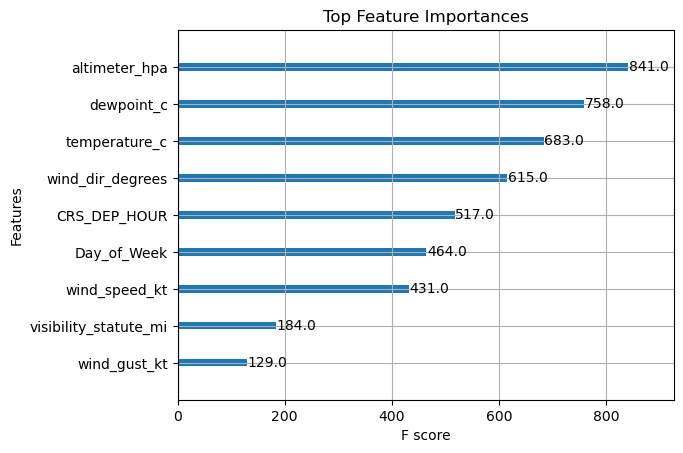

In [61]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plot_importance(xgb_model, max_num_features=15)
plt.title("Top Feature Importances")
plt.show()

In [49]:
#columns 
print(df.columns.tolist())


['FL_DATE', 'wind_dir_degrees', 'wind_speed_kt', 'wind_gust_kt', 'visibility_statute_mi', 'temperature_c', 'dewpoint_c', 'altimeter_hpa', 'Flight_Status', 'Carrier_AA', 'Carrier_AS', 'Carrier_B6', 'Carrier_DL', 'Carrier_F9', 'Carrier_G4', 'Carrier_HA', 'Carrier_NK', 'Carrier_OO', 'Carrier_UA', 'Carrier_WN', 'DEST_REGION', 'Dest_Region_Midwest', 'Dest_Region_Mountain', 'Dest_Region_Northeast', 'Dest_Region_OCONUS', 'Dest_Region_South', 'Dest_Region_Southwest', 'Dest_Region_West', 'Flight_Status_Binary', 'Day_of_Week', 'Is_Weekend', 'CRS_DEP_HOUR', 'Wind_High', 'Wind_Low', 'Wind_Medium']


## Carrier and Region into Numeric true/false to 1/0

In [50]:
## Change True/False to Numeric 1/0
carrier_cols = [col for col in df.columns if col.startswith('Carrier_')]

# Convert Carrier columns
df[carrier_cols] = df[carrier_cols].astype(int)

print(df[carrier_cols].dtypes)
print(df[carrier_cols].head())

Carrier_AA    int64
Carrier_AS    int64
Carrier_B6    int64
Carrier_DL    int64
Carrier_F9    int64
Carrier_G4    int64
Carrier_HA    int64
Carrier_NK    int64
Carrier_OO    int64
Carrier_UA    int64
Carrier_WN    int64
dtype: object
   Carrier_AA  Carrier_AS  Carrier_B6  Carrier_DL  Carrier_F9  Carrier_G4  \
0           0           0           0           1           0           0   
1           0           0           0           1           0           0   
2           1           0           0           0           0           0   
3           0           0           0           1           0           0   
4           0           0           0           1           0           0   

   Carrier_HA  Carrier_NK  Carrier_OO  Carrier_UA  Carrier_WN  
0           0           0           0           0           0  
1           0           0           0           0           0  
2           0           0           0           0           0  
3           0           0           0          

In [51]:
region_cols = [col for col in df.columns if col.startswith('Dest_Region_')]

df[region_cols] = df[region_cols].astype(int)

print(df[region_cols].dtypes)
print(df[region_cols].head())

Dest_Region_Midwest      int64
Dest_Region_Mountain     int64
Dest_Region_Northeast    int64
Dest_Region_OCONUS       int64
Dest_Region_South        int64
Dest_Region_Southwest    int64
Dest_Region_West         int64
dtype: object
   Dest_Region_Midwest  Dest_Region_Mountain  Dest_Region_Northeast  \
0                    1                     0                      0   
1                    0                     1                      0   
2                    0                     0                      0   
3                    0                     0                      0   
4                    1                     0                      0   

   Dest_Region_OCONUS  Dest_Region_South  Dest_Region_Southwest  \
0                   0                  0                      0   
1                   0                  0                      0   
2                   0                  1                      0   
3                   0                  1                      0   
4      

## Which Carriers Are More Likely to Delay?

In [57]:
carrier_cols = [col for col in df.columns if col.startswith('Carrier_')]

# Calculate each carrier
for carrier in carrier_cols:
    delay_rate = df[df[carrier] == 1]['Flight_Status_Binary'].mean()
    print(f"{carrier}: {delay_rate:.2%} delayed")

Carrier_AA: 9.48% delayed
Carrier_AS: 9.39% delayed
Carrier_B6: 17.81% delayed
Carrier_DL: 7.18% delayed
Carrier_F9: 16.17% delayed
Carrier_G4: 28.21% delayed
Carrier_HA: 12.62% delayed
Carrier_NK: 11.76% delayed
Carrier_OO: 7.07% delayed
Carrier_UA: 8.31% delayed
Carrier_WN: 12.98% delayed


## Which Regions Are More Prone to Cancellations?

In [56]:
region_cols = [col for col in df.columns if col.startswith('Dest_Region_')]

for region in region_cols:
    cancel_rate = df[(df[region] == 1) & (df['Flight_Status'] == 'Cancelled')].shape[0] / df[df[region] == 1].shape[0]
    print(f"{region}: {cancel_rate:.2%} cancelled")

Dest_Region_Midwest: 0.85% cancelled
Dest_Region_Mountain: 1.12% cancelled
Dest_Region_Northeast: 1.26% cancelled
Dest_Region_OCONUS: 0.98% cancelled
Dest_Region_South: 1.32% cancelled
Dest_Region_Southwest: 1.46% cancelled
Dest_Region_West: 0.99% cancelled


## Visualizations

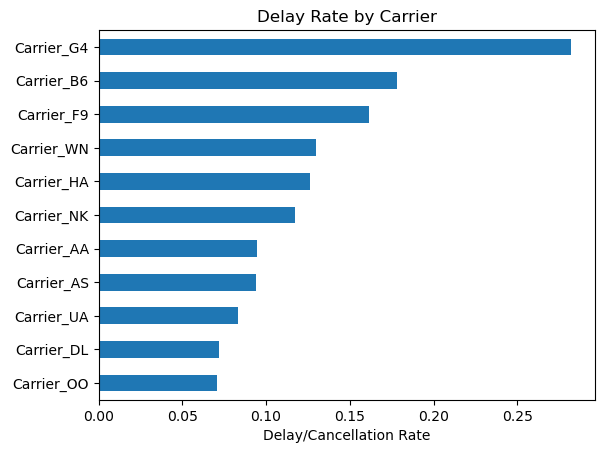

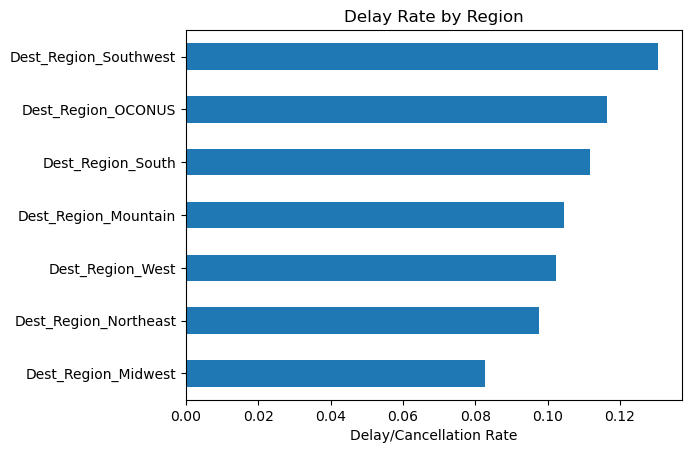

In [58]:
import matplotlib.pyplot as plt

# Carrier delay rates
carrier_rates = {carrier: df[df[carrier] == 1]['Flight_Status_Binary'].mean() for carrier in carrier_cols}
pd.Series(carrier_rates).sort_values().plot(kind='barh', title="Delay Rate by Carrier")
plt.xlabel("Delay/Cancellation Rate")
plt.show()

# Region delay rates
region_rates = {region: df[df[region] == 1]['Flight_Status_Binary'].mean() for region in region_cols}
pd.Series(region_rates).sort_values().plot(kind='barh', title="Delay Rate by Region")
plt.xlabel("Delay/Cancellation Rate")
plt.show()

## Delay rate by carrier to each region

In [59]:
for carrier in carrier_cols:
    for region in region_cols:
        combined = df[(df[carrier] == 1) & (df[region] == 1)]
        if len(combined) > 50:  # skip tiny groups
            rate = combined['Flight_Status_Binary'].mean()
            print(f"{carrier} to {region}: {rate:.2%} delayed")

Carrier_AA to Dest_Region_Midwest: 6.67% delayed
Carrier_AA to Dest_Region_Northeast: 6.08% delayed
Carrier_AA to Dest_Region_South: 10.82% delayed
Carrier_AA to Dest_Region_Southwest: 8.98% delayed
Carrier_AS to Dest_Region_Northeast: 8.49% delayed
Carrier_AS to Dest_Region_OCONUS: 10.41% delayed
Carrier_AS to Dest_Region_South: 9.16% delayed
Carrier_AS to Dest_Region_West: 9.47% delayed
Carrier_B6 to Dest_Region_Northeast: 16.07% delayed
Carrier_B6 to Dest_Region_South: 26.35% delayed
Carrier_DL to Dest_Region_Midwest: 6.22% delayed
Carrier_DL to Dest_Region_Mountain: 8.08% delayed
Carrier_DL to Dest_Region_Northeast: 9.10% delayed
Carrier_DL to Dest_Region_South: 7.34% delayed
Carrier_DL to Dest_Region_West: 5.97% delayed
Carrier_F9 to Dest_Region_Mountain: 12.70% delayed
Carrier_F9 to Dest_Region_South: 27.85% delayed
Carrier_F9 to Dest_Region_Southwest: 16.46% delayed
Carrier_F9 to Dest_Region_West: 2.27% delayed
Carrier_G4 to Dest_Region_Midwest: 25.24% delayed
Carrier_G4 to Dest

## Heatmap

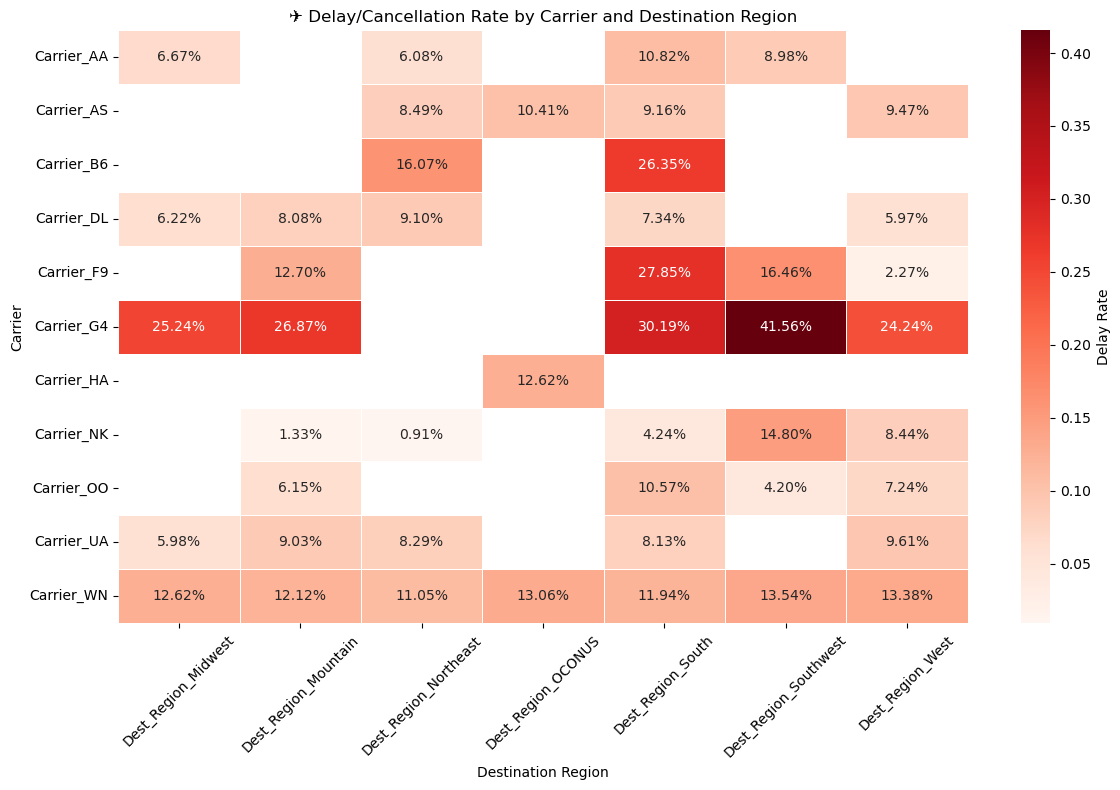

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Create a matrix to store delay rates
heatmap_data = pd.DataFrame(index=carrier_cols, columns=region_cols)

# Step 2: Calculate delay rate for each Carrier x Region combo
for carrier in carrier_cols:
    for region in region_cols:
        combined = df[(df[carrier] == 1) & (df[region] == 1)]
        if len(combined) > 50:  # skip tiny groups
            rate = combined['Flight_Status_Binary'].mean()
            heatmap_data.loc[carrier, region] = rate
        else:
            heatmap_data.loc[carrier, region] = None  # optional: leave blank

# Step 3: Convert values to numeric
heatmap_data = heatmap_data.astype(float)

# Step 4: Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2%", cmap="Reds", linewidths=0.5, cbar_kws={'label': 'Delay Rate'})
plt.title("✈️ Delay/Cancellation Rate by Carrier and Destination Region")
plt.xlabel("Destination Region")
plt.ylabel("Carrier")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()